# 神经网络及其应用第一次实验报告
姓名：邢书一
学号：SA25219056

---

## 一、实验目的
1. 掌握线性回归模型原理，基于混凝土数据集完成抗压强度预测任务。
2. 掌握梯度下降优化方法，理解参数迭代更新过程。

---

## 二、数据集与任务描述
数据集：混凝土抗压强度数据集（Concrete_Data_Yeh.csv）
样本数量：1030条
特征数量：8个（水泥、矿渣、粉煤灰、水、减水剂、粗骨料、细骨料、龄期）
预测目标：混凝土抗压强度csMPa（连续值，回归任务）

---

## 三、实验原理
### 1. 线性回归模型
线性回归假设输出与特征满足线性组合关系：
$$y = w_1x_1 + w_2x_2 + ... + w_nx_n + b$$

对应代码实现：
```python
# 增加一列全1，用于统一计算偏置 b
X_train_b = np.c_[np.ones((...)), X_train_scaled]
# 预测公式：y = X · θ
y_pred = X.dot(theta)
```
其中，加一列1是为了把偏置b放进权重一起计算，让矩阵运算更简洁。

### 2. 损失函数（均方误差 MSE）
使用MSE衡量预测误差，是回归任务标准损失函数：
$$MSE = \frac{1}{m}\sum (y_{pred} - y_{true})^2$$

对应代码：
```python
cost = (1 / (2 * m)) * np.sum(error ** 2)
mse = mean_squared_error(y_test, y_pred)
```
MSE 越小，预测越准确。

### 3. 梯度下降优化
沿损失函数负梯度方向更新参数：
$$\theta = \theta - \eta \cdot \nabla J(\theta)$$

对应代码：
```python
gradient = (1 / m) * X.T.dot(error)
theta = theta - learning_rate * gradient
```

---

## 四、实验步骤
1. 读取数据：使用pandas读取csv文件，查看数据结构。
2. 相关性分析：计算特征与抗压强度的相关系数，识别关键特征。
3. 数据集划分：按8:2分为训练集与测试集。
4. 特征标准化：使用StandardScaler缩放特征，保证梯度下降稳定。
5. 构造增广矩阵：添加一列1，用于统一求解权重w和偏置b。
6. 梯度下降训练：迭代更新权重，记录损失变化。
7. 模型评估：计算MSE、RMSE、R²指标。
8. 可视化：绘制损失下降曲线、真实值与预测值对比图。

---

## 五、实验结果与分析
1. 相关性分析表明，水泥、龄期与混凝土抗压强度呈较强正相关，是影响强度的主要特征，与模型学到的特征权重结果一致。
2. 模型在测试集上的评估指标为：MSE=98.27，RMSE=9.91，R²=0.62，说明模型整体拟合效果较好，能解释数据中62%的方差。
3. 梯度下降损失曲线平稳收敛，表明迭代过程正常，学习率与参数设置合理。
4. 真实值与预测值散点图分布接近理想对角线，模型预测偏差较小，拟合效果合理。

---

## 六、实验结论
1. 本次实验实现了线性回归 + 梯度下降模型。
2. 完成了回归任务的全流程，模型能够有效预测混凝土抗压强度。
3. 理解了线性回归原理、梯度下降过程及模型评估方法，达到实验要求。


特征与抗压强度相关性：
csMPa               1.000000
cement              0.497832
superplasticizer    0.366079
age                 0.328873
slag                0.134829
flyash             -0.105755
coarseaggregate    -0.164935
fineaggregate      -0.167241
water              -0.289633
Name: csMPa, dtype: float64

===== 梯度下降线性回归 模型评估 =====
MSE  : 98.27
RMSE : 9.91
R²   : 0.62

特征权重（回归系数）：
cement             : 8.4071
slag               : 5.1739
flyash             : 1.3676
water              : -5.7210
superplasticizer   : 2.1571
coarseaggregate    : -1.5010
fineaggregate      : -1.9247
age                : 6.8291


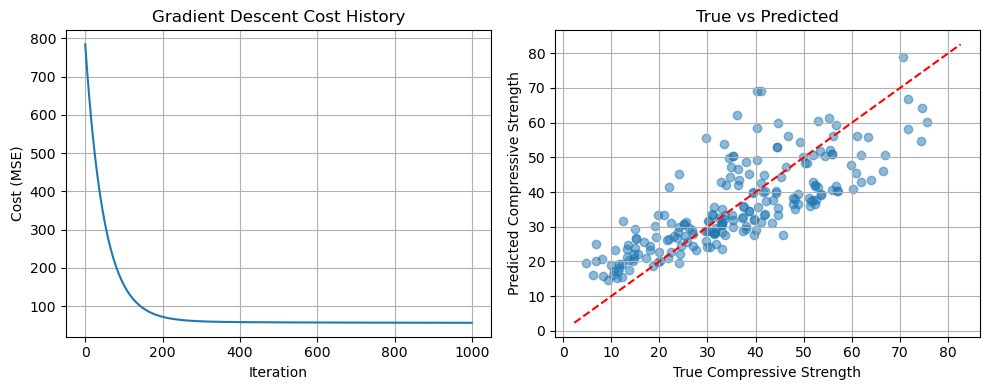

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# =====================读取数据=====================
df = pd.read_csv("Concrete_Data_Yeh.csv")

# 特征与标签
X = df.drop("csMPa", axis=1).values
y = df["csMPa"].values

# =====================相关性分析=====================
corr = df.corr()
print("\n特征与抗压强度相关性：")
print(corr["csMPa"].sort_values(ascending=False))

# =====================划分训练集/测试集（8:2）=====================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =====================标准化=====================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 在特征前加一列 1，用于计算截距（偏置 b）
X_train_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_b = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

# =====================梯度下降线性回归=====================
def gradient_descent(X, y, learning_rate=0.01, n_iterations=1000):
    m = len(y)
    theta = np.zeros(X.shape[1])  # 初始化权重 w 和偏置 b 为 0
    cost_history = []  # 记录损失变化

    for i in range(n_iterations):
        # 预测值h = X @ theta
        y_pred = X.dot(theta)
        
        # 误差
        error = y_pred - y
        
        # 梯度
        gradient = (1 / m) * X.T.dot(error)
        
        # 更新权重
        theta = theta - learning_rate * gradient
        
        # 记录MSE损失
        cost = (1 / (2 * m)) * np.sum(error ** 2)
        cost_history.append(cost)

    return theta, cost_history

# 训练模型
theta, cost_history = gradient_descent(X_train_b, y_train, learning_rate=0.01, n_iterations=1000)

# 提取参数
b = theta[0]  # 偏置
w = theta[1:] # 特征权重

# ===================== 预测与评估 =====================
y_pred = X_test_b.dot(theta)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n===== 梯度下降线性回归 模型评估 =====")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.2f}")

# 输出权重
print("\n特征权重（回归系数）：")
for name, coef in zip(df.drop("csMPa", axis=1).columns, w):
    print(f"{name:18s} : {coef:.4f}")

# ====================图像======================
# 图1：损失下降曲线
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost (MSE)")
plt.title("Gradient Descent Cost History")
plt.grid(True)

# 图2：真实值 vs 预测值
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.xlabel("True Compressive Strength")
plt.ylabel("Predicted Compressive Strength")
plt.title("True vs Predicted")
plt.grid(True)

plt.tight_layout()
plt.show()